In [1]:
from random import randint

import numpy as np
import pennylane as qml
from regex import P
import torch as t
from einops import rearrange, reduce, repeat
from qiskit.result import marginal_counts
from qiskit.visualization import plot_distribution
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider.fake_provider import FakeTorino, FakeKyiv
from qiskit_aer import AerSimulator

from architecture import Hybrid
from architecture.quantum import VQC
from data_modules import EntangledConceptDataModule
from utils.circuits import create_circuit
import matplotlib.pyplot as plt

t.set_grad_enabled(False)

In [2]:
blackbird = EntangledConceptDataModule("blackbird/data/balanced", "blackbird", 2**6)
config = blackbird.config

blackbird_model = Hybrid.load_from_checkpoint(
    "lightning_logs/blackbird/checkpoints/blackbird-selection-epoch=44.ckpt"
)
distribute_three_model = Hybrid.load_from_checkpoint(
    "lightning_logs/distribute_three/checkpoints/distribute_three-selection-epoch=83.ckpt"
)
progression_model = Hybrid.load_from_checkpoint(
    "lightning_logs/progression/checkpoints/progression-selection-epoch=81.ckpt"
)

Balance of blackbird/data/balanced/train-blackbird dataset: 0.5130000114440918 true
Balance of blackbird/data/balanced/val-blackbird dataset: 0.4699999988079071 true
Balance of blackbird/data/balanced/test-blackbird dataset: 0.5433333516120911 true


In [3]:
dataloader = blackbird.test_dataloader()
instances, labels = next(iter(dataloader))
instances, labels = instances.to(blackbird_model.device), labels.to(
    blackbird_model.device
)
property_labels = np.array(dataloader.dataset.properties)
property_labels = rearrange(
    property_labels, "puzzle (row column type) -> puzzle type row column", row=3, type=2
)
property_labels = property_labels[labels.cpu().numpy() == 1]

encoder = blackbird_model.encoder
distribute_three = distribute_three_model.vqc
progression = progression_model.vqc

Row


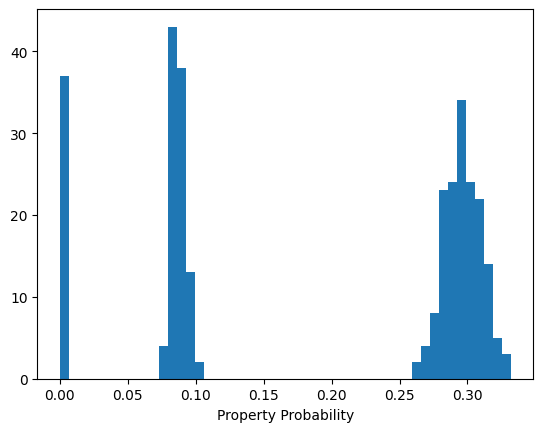

Positive
min: 0.26057895478229853 mean: 0.2963099282950608 std: 0.013413044142709371
Negative
max: 0.10378945753993117 mean: 0.06382909358084927 std: 0.03895397418525569

Column


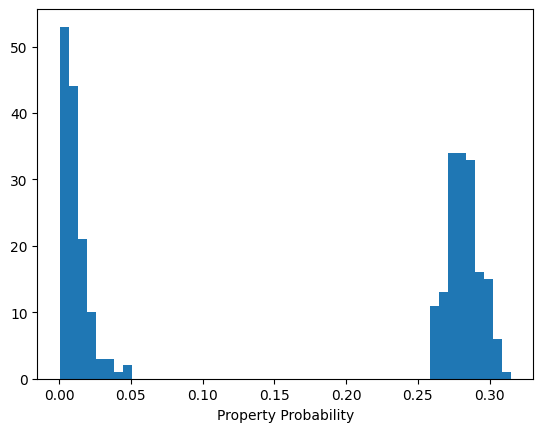

Positive
min: 0.25849458028537714 mean: 0.2822529967080359 std: 0.011225101633603556
Negative
max: 0.04980012441699852 mean: 0.01110980494711801 std: 0.009308964713243486

Puzzle


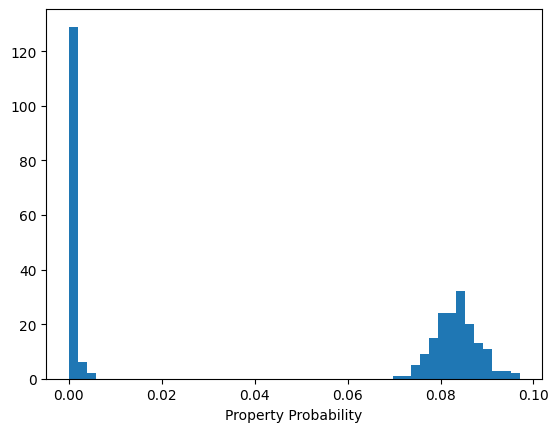

Positive
min: 0.0712117202446004 mean: 0.08361385983357957 std: 0.00467843299995455
Negative
max: 0.004677650855694321 mean: 0.000709479308802264 std: 0.0008241539013866091

Blackbird detection accuracy: 1.0


In [4]:
encodings = encoder(instances, config.images_per_instance)
encodings = rearrange(
    encodings,
    "puzzle (row column domain) encoding -> puzzle row column domain encoding",
    row=3,
    column=3,
    domain=2,
)

row = rearrange(
    encodings,
    "puzzle row column domain encoding -> (puzzle row) (column domain) encoding",
)
column = rearrange(
    encodings,
    "puzzle row column domain encoding -> (puzzle column) (row domain) encoding",
)

row_probs = distribute_three(row, None)
row_probs = reduce(row_probs, "(puzzle row) -> puzzle", "prod", row=3)

column_probs = progression(column, None)
column_probs = reduce(
    column_probs, "(puzzle column) -> puzzle", "prod", column=3
)

probs = t.stack([row_probs, column_probs], dim=1)
probs = reduce(probs, "puzzle orientation -> puzzle", "prod")


# TODO: plot instead
def print_stats(probs, labels):
    plt.hist(probs.cpu().detach().flatten(), bins=50)
    plt.xlabel('Property Probability')
    plt.show()
    
    print("Positive")
    print(f"min: {probs[labels == 1].min()}", end=" ")
    print(f"mean: {probs[labels == 1].mean()}", end=" ")
    print(f"std: {probs[labels == 1].std()}")
    print("Negative")
    print(f"max: {probs[labels == 0].max()}", end=" ")
    print(f"mean: {probs[labels == 0].mean()}", end=" ")
    print(f"std: {probs[labels == 0].std()}\n")


print("Row")
print_stats(row_probs, labels)
print("Column")
print_stats(column_probs, labels)
print("Puzzle")
print_stats(probs, labels)

preds = probs > 0.5**6
accuracy = (preds == labels).float().mean()
print(f"Blackbird detection accuracy: {accuracy}")

In [5]:
properties = blackbird_model.config.properties
offsets = blackbird_model.config.offsets

property_encodings = blackbird_model.vqc.concept_weights.weight.detach()
color_encodings = property_encodings[offsets[0] : offsets[0] + len(properties[0])]
position_encodings = property_encodings[offsets[1] : offsets[1] + len(properties[1])]

In [6]:
# influences position circuit and selects color constraint
missing_row = 0 #randint(0, 2)
# influences color circuit and selects position constraint
missing_column = 0 #randint(0, 2)

print(f"Missing panel at ({missing_row}, {missing_column})")

Missing panel at (0, 0)


In [7]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return color_accuracy and position_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    # c_probs = rearrange(
    #     color_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    # p_probs = rearrange(
    #     position_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


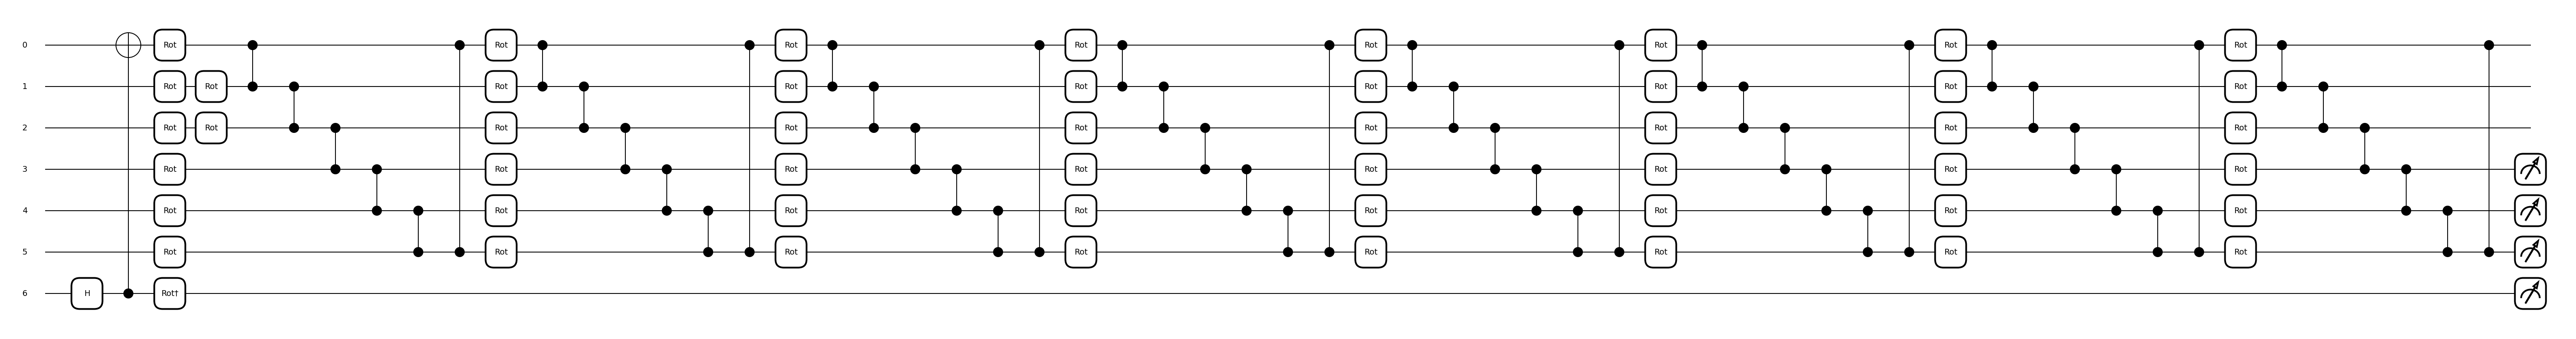

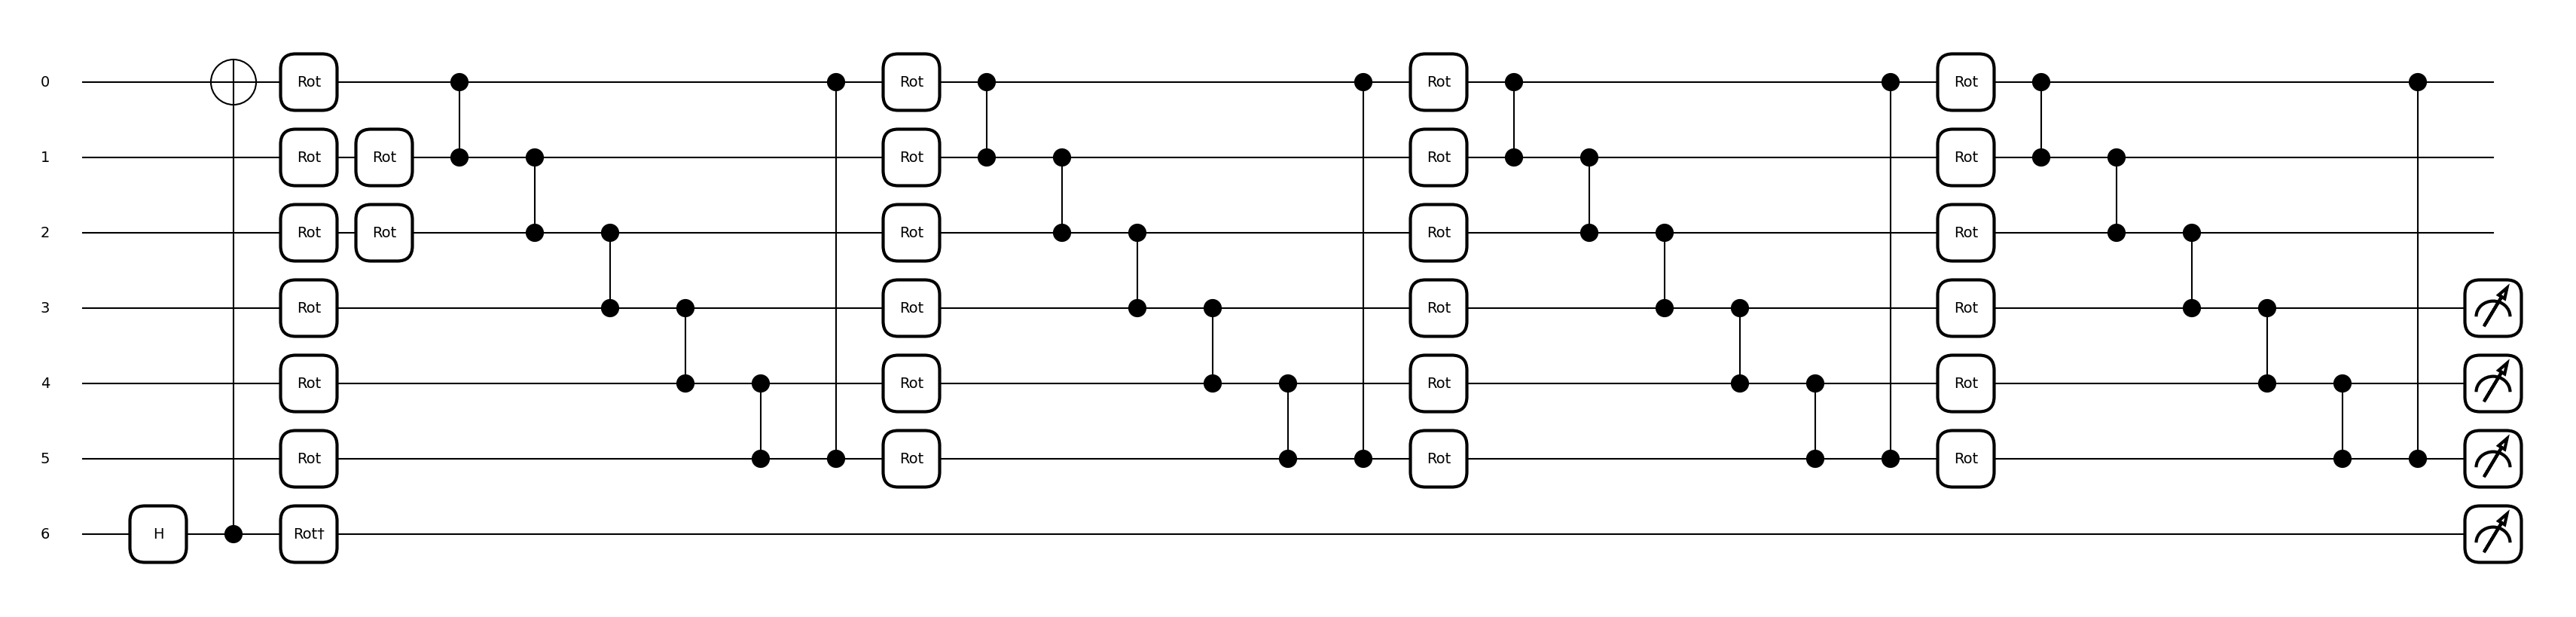

In [8]:
dev = qml.device("default.qubit", wires=10)

color_circuit = create_and_visualise_circuit(distribute_three, dev, row_wise=True)
position_circuit = create_and_visualise_circuit(progression, dev, row_wise=False)

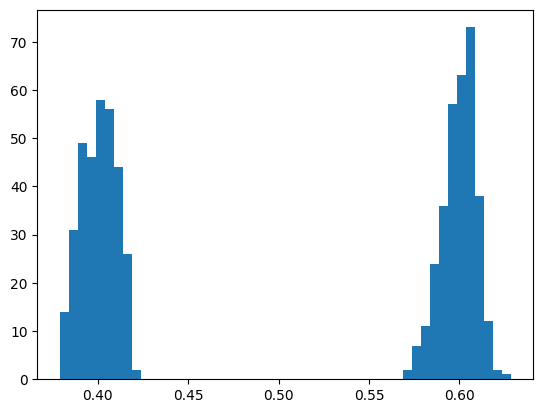

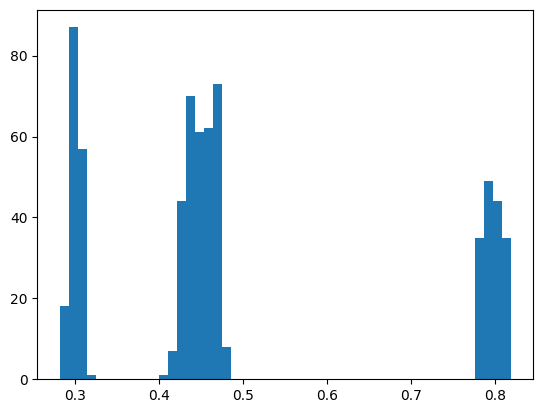

Blackbird solving accuracy: 1.0 (163 puzzles)
Found 86 new solutions out of 163 solved puzzles


In [9]:
full_color_probs = make_property_predictions(
    distribute_three,
    color_circuit,
    encodings[labels == 1],
    color_encodings,
    row_wise=True,
)
full_position_probs = make_property_predictions(
    progression,
    position_circuit,
    encodings[labels == 1],
    position_encodings,
    row_wise=False,
)

check_predictions(full_color_probs, full_position_probs, property_labels)

<ipython-input-10-2182eaf0ac7a>:11: DeprecationWarning: The class ``qiskit.providers.models.backendconfiguration.QasmBackendConfiguration`` is deprecated as of qiskit 1.2. It will be removed in the 2.0 release. The models in ``qiskit.providers.models`` are part of the deprecated `BackendV1` workflow and no longer necessary for `BackendV2`. If a user workflow requires these representations it likely relies on deprecated functionality and should be updated to use `BackendV2`.
  backend = AerSimulator.from_backend(backend)


aer_simulator_from(ibm_kyiv): 0 pending jobs


<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


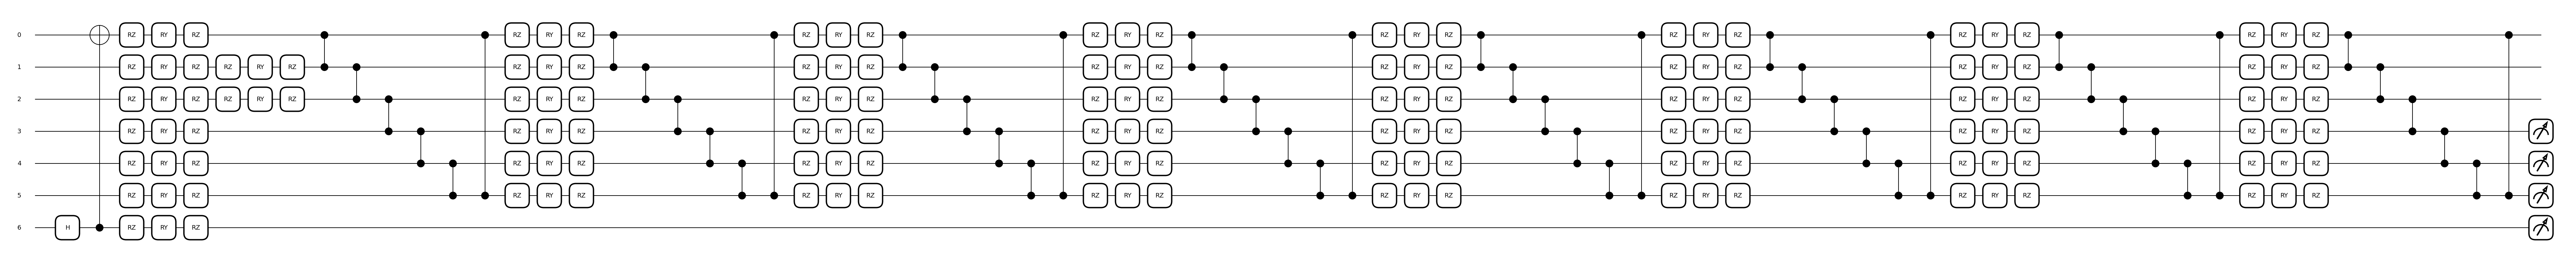

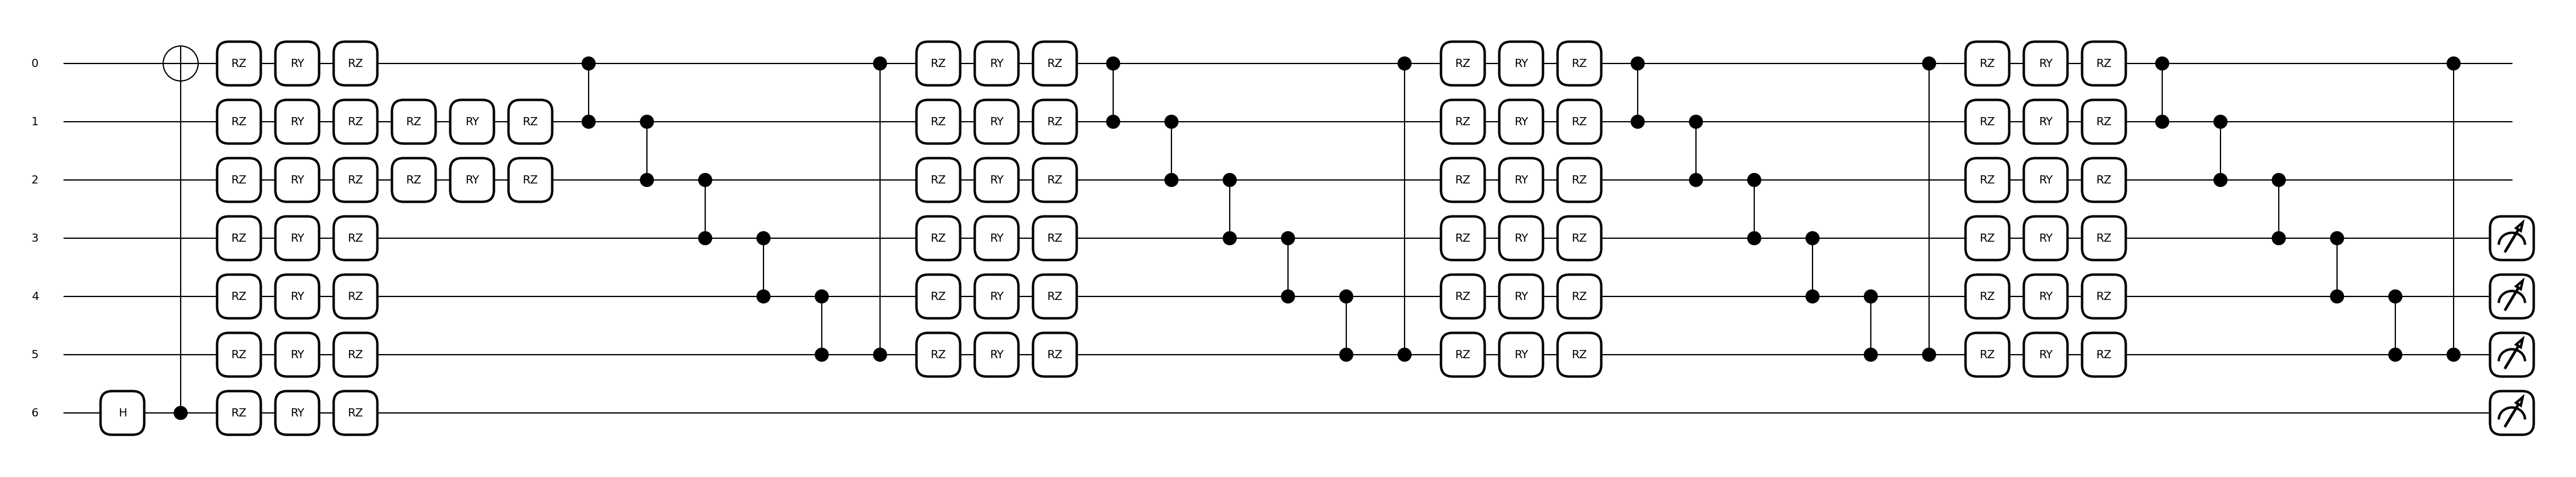

In [10]:
service = QiskitRuntimeService(channel="ibm_quantum", instance="ibm-q/open/main")

# backend = FakeKyiv()
# print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")


# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=7)
backend = service.backend("ibm_kyiv")
backend = AerSimulator.from_backend(backend)
print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")

dev = qml.device("qiskit.remote", wires=7, backend=backend, shots=2**14,     
    resilience_level=1,
    optimization_level=1,
    seed_transpiler=42)

# dev = qml.device("default.qubit", wires=10)

color_circuit = create_and_visualise_circuit(distribute_three, dev, row_wise=True)
position_circuit = create_and_visualise_circuit(progression, dev, row_wise=False)

# job = service.jobs()[0]
# result = job.result()

# plot_distribution(result.get_counts(0), number_to_keep=20)

# marginal = marginal_counts(result, [0])
# plot_distribution(marginal.get_counts(0), number_to_keep=20)

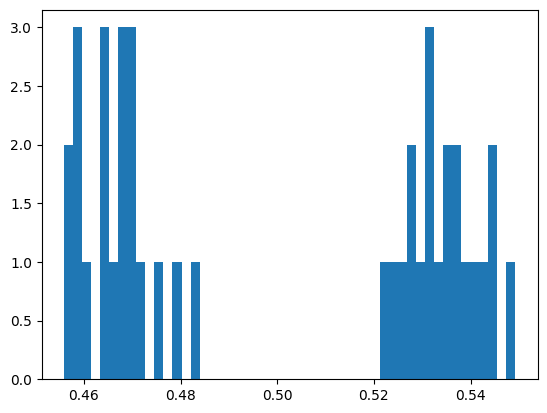

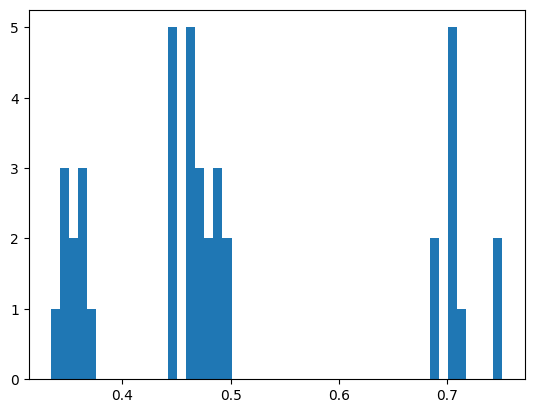

Blackbird solving accuracy: 1.0 (10 puzzles)
Found 5 new solutions out of 10 solved puzzles
CPU times: user 1min 5s, sys: 2.99 s, total: 1min 8s
Wall time: 21.1 s


In [11]:
%%time

amount = 10 #len(labels[labels == 1])
batch = 0

# 0: 12, 0, 0 -> 0
# 1 color: 12, 2, 2 botched
# 1: 13, 2, 2 -> 1 (color 4)
# 2: 14, 2, 2

r = range(batch*amount, (batch+1)*amount)

full_color_probs = make_property_predictions(
    distribute_three,
    color_circuit,
    encodings[labels == 1][r],
    color_encodings,
    row_wise=True,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_color_probs, f"full_color_probs_batch{batch}.pt")

full_position_probs = make_property_predictions(
    progression,
    position_circuit,
    encodings[labels == 1][r],
    position_encodings,
    row_wise=False,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_position_probs, f"full_position_probs_batch{batch}.pt")

check_predictions(full_color_probs, full_position_probs, property_labels[r])

<ipython-input-12-afeb7f89a53f>:11: DeprecationWarning: The class ``qiskit.providers.models.backendconfiguration.QasmBackendConfiguration`` is deprecated as of qiskit 1.2. It will be removed in the 2.0 release. The models in ``qiskit.providers.models`` are part of the deprecated `BackendV1` workflow and no longer necessary for `BackendV2`. If a user workflow requires these representations it likely relies on deprecated functionality and should be updated to use `BackendV2`.
  backend = AerSimulator.from_backend(backend)


aer_simulator_from(ibm_kyiv): 0 pending jobs


<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


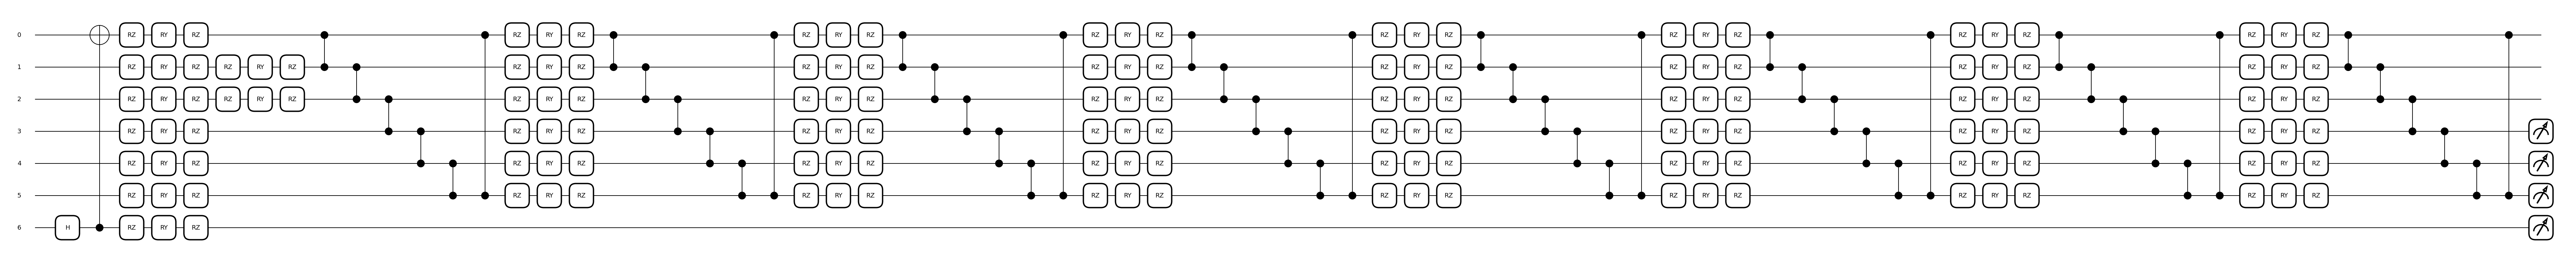

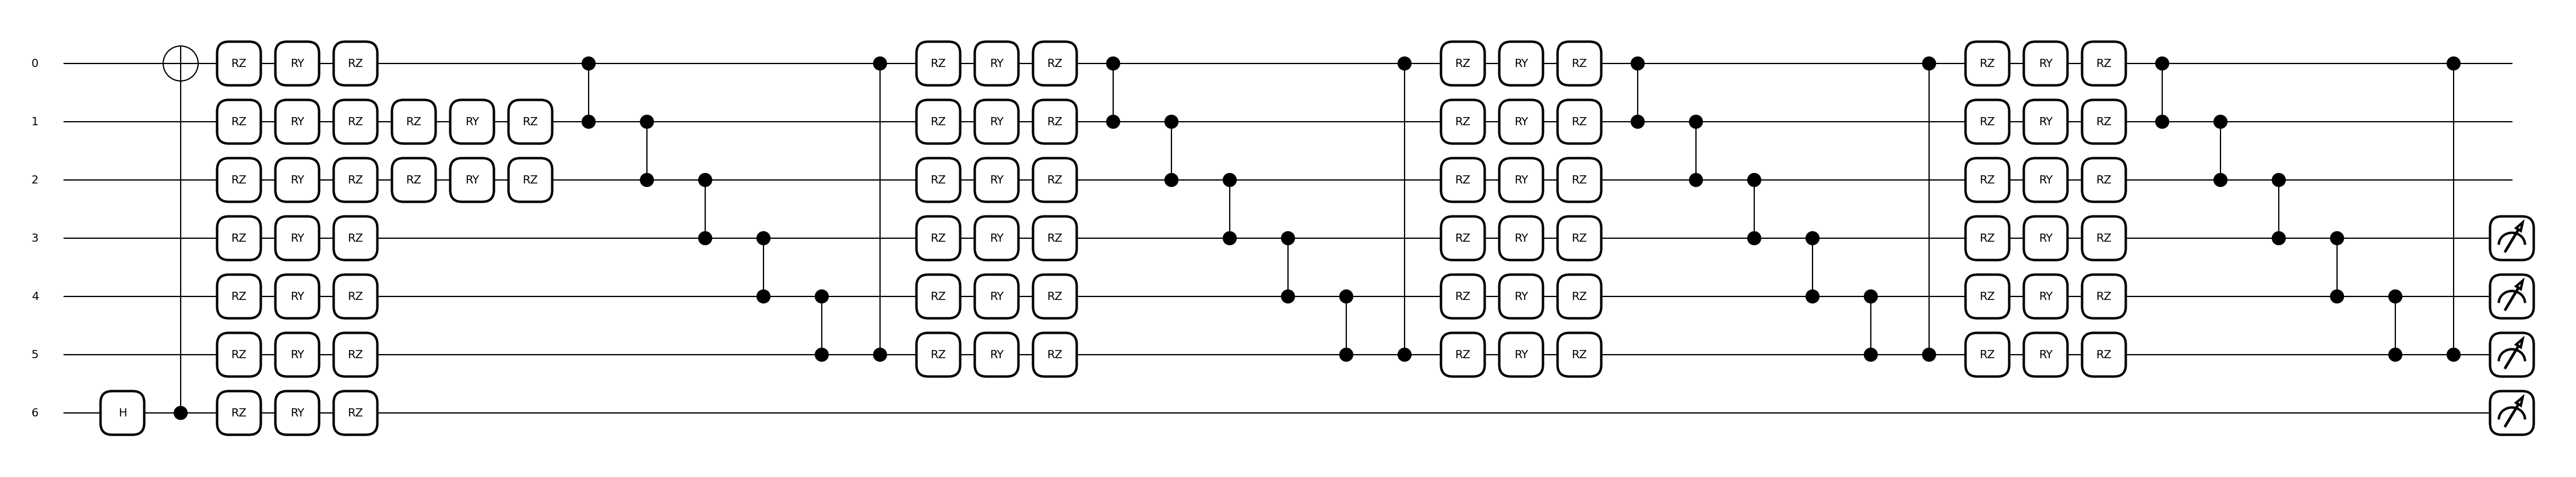

In [12]:
service = QiskitRuntimeService(channel="ibm_quantum", instance="ibm-q/open/main")

# backend = FakeKyiv()
# print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")


# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=7)
backend = service.backend("ibm_kyiv")
backend = AerSimulator.from_backend(backend)
print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")

dev = qml.device("qiskit.remote", wires=7, backend=backend, shots=2**14,     
    resilience_level=2,
    optimization_level=2,
    seed_transpiler=42)

# dev = qml.device("default.qubit", wires=10)

color_circuit = create_and_visualise_circuit(distribute_three, dev, row_wise=True)
position_circuit = create_and_visualise_circuit(progression, dev, row_wise=False)

# job = service.jobs()[0]
# result = job.result()

# plot_distribution(result.get_counts(0), number_to_keep=20)

# marginal = marginal_counts(result, [0])
# plot_distribution(marginal.get_counts(0), number_to_keep=20)

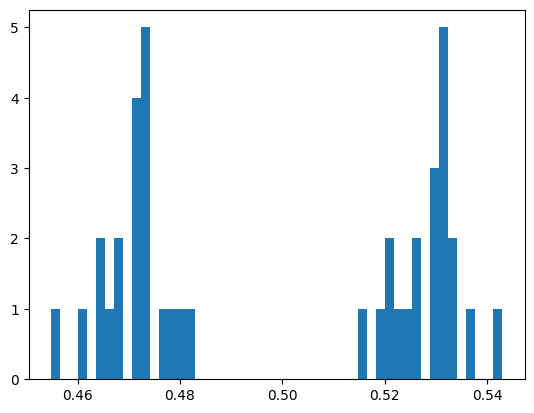

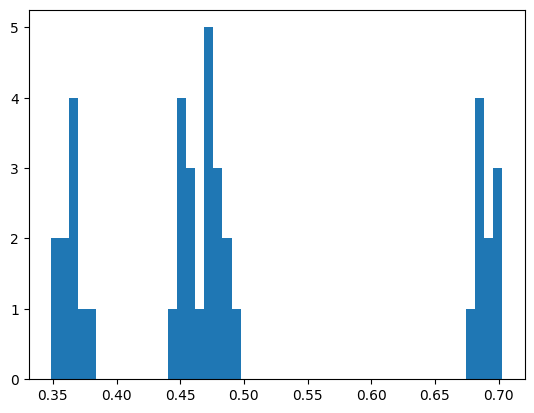

Blackbird solving accuracy: 1.0 (10 puzzles)
Found 4 new solutions out of 10 solved puzzles
CPU times: user 1min 43s, sys: 2.92 s, total: 1min 46s
Wall time: 26.1 s


In [13]:
%%time

amount = 10 #len(labels[labels == 1])
batch = 0

# 0: 12, 0, 0 -> 0
# 1 color: 12, 2, 2 botched
# 1: 13, 2, 2 -> 1 (color 4)
# 2: 14, 2, 2

r = range(batch*amount, (batch+1)*amount)

full_color_probs = make_property_predictions(
    distribute_three,
    color_circuit,
    encodings[labels == 1][r],
    color_encodings,
    row_wise=True,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_color_probs, f"full_color_probs_batch{batch}.pt")

full_position_probs = make_property_predictions(
    progression,
    position_circuit,
    encodings[labels == 1][r],
    position_encodings,
    row_wise=False,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_position_probs, f"full_position_probs_batch{batch}.pt")

check_predictions(full_color_probs, full_position_probs, property_labels[r])

ibm_kyiv: 2939 pending jobs


<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
<ipython-input-7-8dd063f19b6f>:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


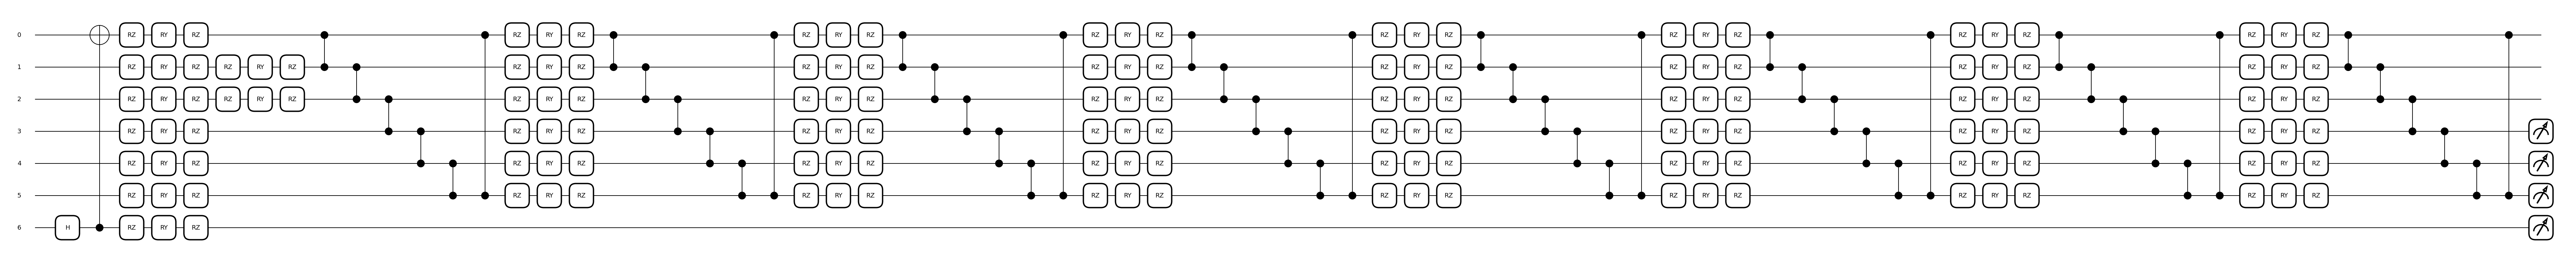

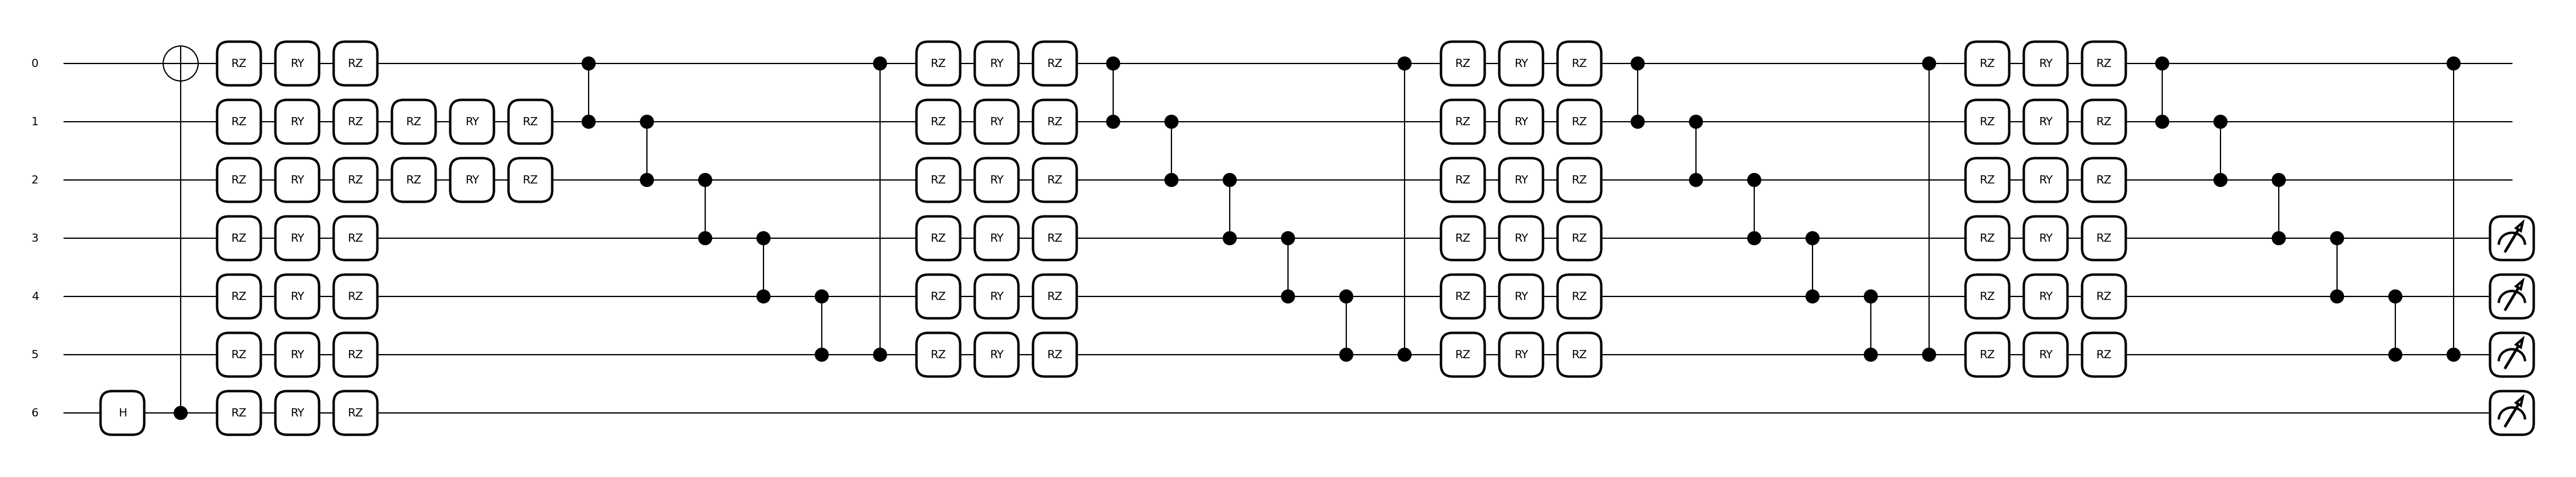

In [14]:
service = QiskitRuntimeService(channel="ibm_quantum", instance="ibm-q/open/main")

# backend = FakeKyiv()
# print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")


# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=7)
backend = service.backend("ibm_kyiv")
# backend = AerSimulator.from_backend(backend)
print(f"{backend.name}: {backend.status().pending_jobs} pending jobs")

dev = qml.device("qiskit.remote", wires=7, backend=backend, shots=2**14,     
    resilience_level=2,
    optimization_level=2,
    seed_transpiler=42)

# dev = qml.device("default.qubit", wires=10)

color_circuit = create_and_visualise_circuit(distribute_three, dev, row_wise=True)
position_circuit = create_and_visualise_circuit(progression, dev, row_wise=False)

# job = service.jobs()[0]
# result = job.result()

# plot_distribution(result.get_counts(0), number_to_keep=20)

# marginal = marginal_counts(result, [0])
# plot_distribution(marginal.get_counts(0), number_to_keep=20)

In [15]:
%%time

amount = 10 #len(labels[labels == 1])
batch = 0

# 0: 12, 0, 0 -> 0
# 1 color: 12, 2, 2 botched
# 1: 13, 2, 2 -> 1 (color 4)
# 2: 14, 2, 2

r = range(batch*amount, (batch+1)*amount)

full_color_probs = make_property_predictions(
    distribute_three,
    color_circuit,
    encodings[labels == 1][r],
    color_encodings,
    row_wise=True,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_color_probs, f"full_color_probs_batch{batch}.pt")

full_position_probs = make_property_predictions(
    progression,
    position_circuit,
    encodings[labels == 1][r],
    position_encodings,
    row_wise=False,
)
if dev.name == "Qiskit PennyLane plugin" and "fake" not in backend.name:
    t.save(full_position_probs, f"full_position_probs_batch{batch}.pt")

check_predictions(full_color_probs, full_position_probs, property_labels[r])

/usr/lib/python3.10/contextlib.py:79: UserWarning: resilience_level is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kwds)
/usr/lib/python3.10/contextlib.py:79: UserWarning: optimization_level is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kwds)
/usr/lib/python3.10/contextlib.py:79: UserWarning: seed_transpiler is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kwds)
/usr/lib/python3.10/contextlib.py:79: UserWarning: resilience_level is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kwds)
/usr/lib/python3.10/contextlib.py:79: UserWarning: optimization_level is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kwds)
/usr/lib/python3.10/contextlib.py:79: UserWarning: seed_transpiler is not a recognized runtime option and may be ignored by the backend.
  return func(*args, **kw

IBMBackendApiError: 'Error submitting job: \'403 Client Error: Forbidden for url: https://api.quantum.ibm.com/runtime/jobs. {"errors":[{"message":"Job create exceeds open plan job usage limits","code":4317,"solution":"Please wait until the beginning of next month to submit more jobs when your quota will reset.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}\''

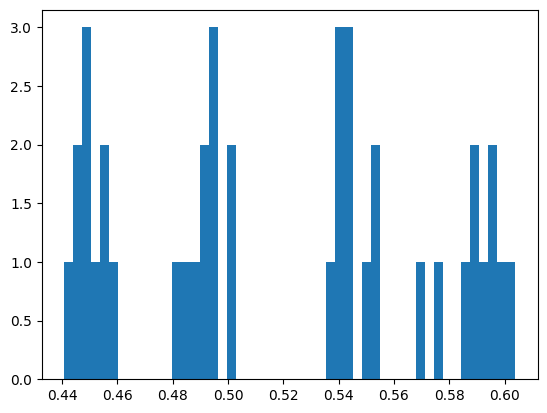

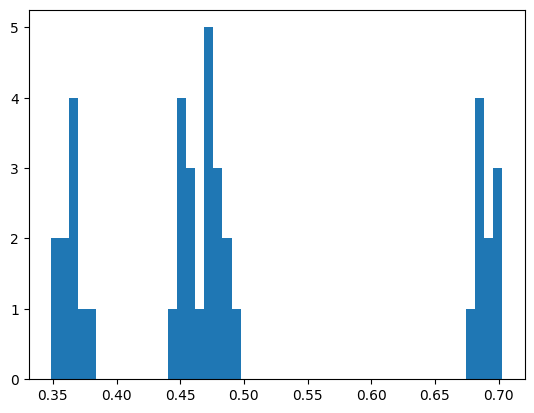

Blackbird solving accuracy: 0.6 (10 puzzles)
Found 2 new solutions out of 6 solved puzzles


In [16]:
check_predictions(full_color_probs, full_position_probs, property_labels[r])

In [17]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return color_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    # c_probs = rearrange(
    #     color_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    # p_probs = rearrange(
    #     position_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

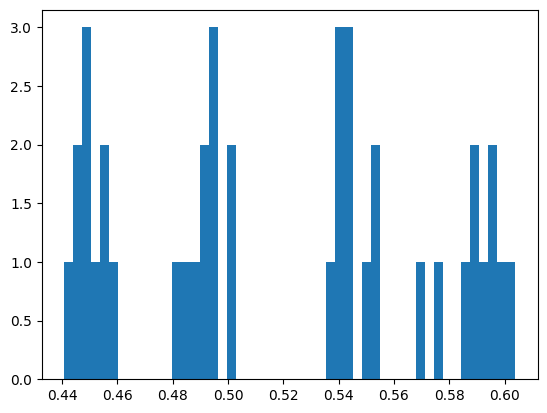

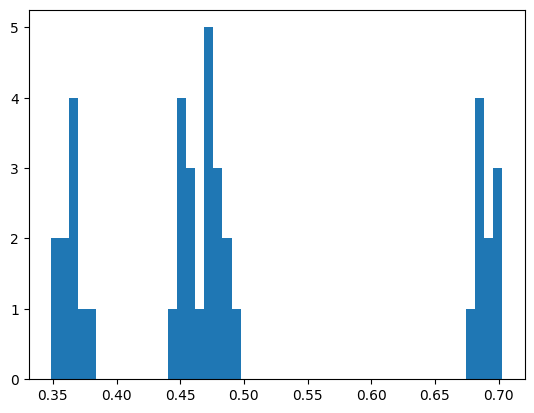

Blackbird solving accuracy: 0.6 (10 puzzles)
Found 2 new solutions out of 6 solved puzzles


In [18]:
check_predictions(full_color_probs, full_position_probs, property_labels[r])

In [19]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return  position_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    # c_probs = rearrange(
    #     color_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    # p_probs = rearrange(
    #     position_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

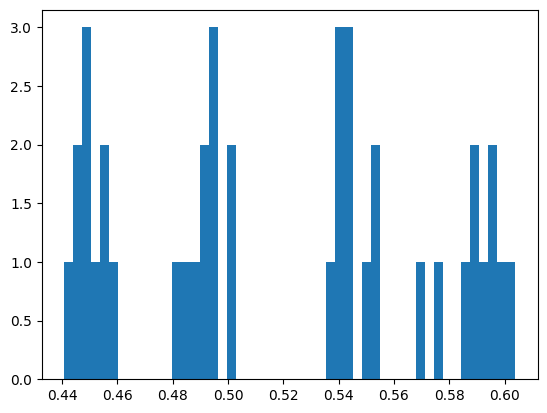

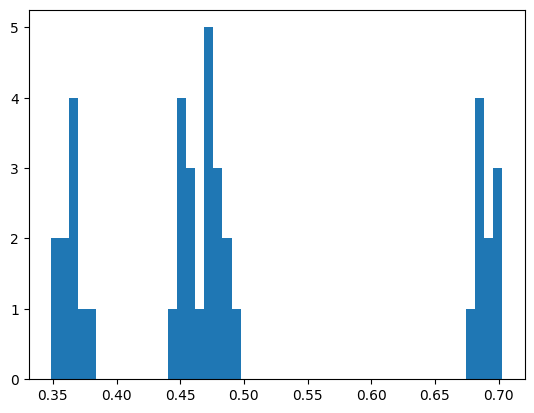

Blackbird solving accuracy: 1.0 (10 puzzles)
Found 6 new solutions out of 10 solved puzzles


In [20]:
check_predictions(full_color_probs, full_position_probs, property_labels[r])

In [21]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return color_accuracy and position_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    # c_probs = rearrange(
    #     color_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    # p_probs = rearrange(
    #     position_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

In [22]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return color_accuracy and position_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    c_probs = rearrange(
        color_probs[:, 0],
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0],
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

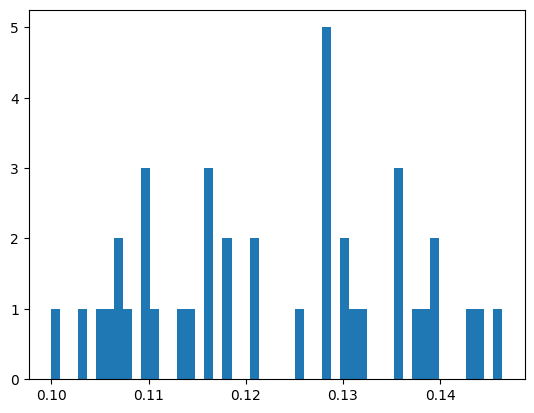

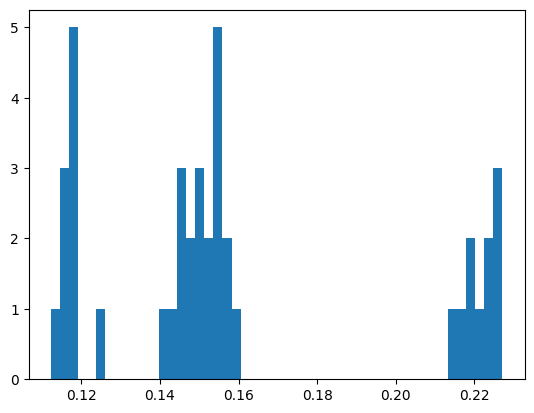

Blackbird solving accuracy: 0.6 (10 puzzles)
Found 2 new solutions out of 6 solved puzzles


In [23]:
check_predictions(full_color_probs, full_position_probs, property_labels[r])

In [24]:
# SIMPLIFIED

def create_and_visualise_circuit(
    vqc: VQC, dev: qml.Device, row_wise: bool
) -> qml.QNode:
    circuit = qml.QNode(
        create_circuit(
            "generative",
            3,
            list(range(3)),
            missing_domain_index=missing_column if row_wise else missing_row,
        ),
        dev,
        interface="torch",
    )

    instance = t.zeros(3, 3)
    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )
    output_property = t.zeros(1, 3)

    fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
        instance, concept, output_property
    )
    fig.show()

    return circuit


def make_property_predictions(
    vqc: VQC,
    circuit: qml.QNode,
    instance_encodings: t.Tensor,
    property_encodings: t.Tensor,
    row_wise: bool,
) -> t.Tensor:
    if row_wise:
        row = repeat(
            instance_encodings[:, missing_row, :, 0],
            "puzzle column encoding -> (column) encoding (puzzle property)",
            property=len(property_encodings),
        )
    else:  # if column-wise, replace row with column
        row = repeat(
            instance_encodings[:, :, missing_column, 1],
            "puzzle row encoding -> (row) encoding (puzzle property)",
            property=len(property_encodings),
        )

    concept = rearrange(
        vqc.concept_weights.weight.detach(),
        "none (layer domain weights) -> (none layer) domain weights",
        layer=vqc.config.layers,
        weights=3,
    )

    # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
    conjugated_properties = -property_encodings.clone()
    conjugated_properties[:, 1] *= -1
    properties = repeat(
        conjugated_properties,
        "property (encoding) -> domain encoding (puzzle property)",
        puzzle=len(instance_encodings),
        domain=1,
    )

    # print(row.shape, concept.shape, properties.shape)

    full_probs = circuit(row, concept, properties)
    return full_probs

# DEFAULT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "generative",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, output_property
#     )
#     fig.show()

#     return circuit


# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = -property_encodings.clone()
#     conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept, properties)

#     return full_probs

# FLAT

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             vqc.config.num_instance_domains,
#             vqc.config.concept_domain_indices,
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(vqc.config.num_instance_domains, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> t.Tensor:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :],
#             "puzzle column domain encoding -> (column domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column],
#             "puzzle row domain encoding -> (row domain) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     if row_wise:
#         row[0:1] = properties
#     else:
#         row[1:2] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

# FLAT SIMPLIFIED

# def create_and_visualise_circuit(
#     vqc: VQC, dev: qml.Device, row_wise: bool
# ) -> qml.QNode:
#     circuit = qml.QNode(
#         create_circuit(
#             "general",
#             3,
#             list(range(3)),
#             # missing_domain_index=missing_column if row_wise else missing_row,
#         ),
#         dev,
#         interface="torch",
#     )

#     instance = t.zeros(3, 3)
#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )
#     output_property = t.zeros(1, 3)

#     fig, axes = qml.draw_mpl(circuit, style="black_white", expansion_strategy="device")(
#         instance, concept, # output_property
#     )
#     fig.show()

#     return circuit

# def make_property_predictions(
#     vqc: VQC,
#     circuit: qml.QNode,
#     instance_encodings: t.Tensor,
#     property_encodings: t.Tensor,
#     row_wise: bool,
# ) -> tuple[t.Tensor, t.Tensor]:
#     if row_wise:
#         row = repeat(
#             instance_encodings[:, missing_row, :, 0],
#             "puzzle column encoding -> (column) encoding (puzzle property)",
#             property=len(property_encodings),
#         )
#     else:  # if column-wise, replace row with column
#         row = repeat(
#             instance_encodings[:, :, missing_column, 1],
#             "puzzle row encoding -> (row) encoding (puzzle property)",
#             property=len(property_encodings),
#         )

#     concept = rearrange(
#         vqc.concept_weights.weight.detach(),
#         "none (layer domain weights) -> (none layer) domain weights",
#         layer=vqc.config.layers,
#         weights=3,
#     )

#     # property is encoded as qml.Rot=RzRyRz, so we need to negate to get the complex conjugate
#     conjugated_properties = property_encodings.clone()
#     # conjugated_properties[:, 1] *= -1
#     properties = repeat(
#         conjugated_properties,
#         "property (encoding) -> domain encoding (puzzle property)",
#         puzzle=len(instance_encodings),
#         domain=1,
#     )
    
#     row[0:1] = properties

#     # print(row.shape, concept.shape, properties.shape)

#     full_probs = circuit(row, concept)
#     return full_probs

def check_color(colors: np.ndarray):
    valid_colors = ["red", "green", "blue", "yellow"]
    return np.unique(colors).size == 3 and all(
        color in valid_colors for color in colors
    )


def check_position(positions: np.ndarray):
    return (
        (positions == np.array(["bottom_left", "top_left", "top_right"])).all()
        or (positions == np.array(["top_left", "top_right", "bottom_right"])).all()
        or (positions == np.array(["top_right", "bottom_right", "bottom_left"])).all()
        or (positions == np.array(["bottom_right", "bottom_left", "top_left"])).all()
    )


def check_puzzle(puzzle: np.ndarray):
    color_accuracy = np.apply_along_axis(check_color, 1, puzzle[0]).all()
    position_accuracy = np.apply_along_axis(check_position, 0, puzzle[1]).all()
    return color_accuracy and position_accuracy


def check_predictions(color_probs, position_probs, property_labels):    
    c_probs = rearrange(
        color_probs[:, 0] / (color_probs[:, 1] + color_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    p_probs = rearrange(
        position_probs[:, 0] / (position_probs[:, 1] + position_probs[:, 0]),
        "(puzzle property) -> puzzle property",
        puzzle=len(property_labels),
    )
    
    # c_probs = rearrange(
    #     color_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    # p_probs = rearrange(
    #     position_probs[:, 0],
    #     "(puzzle property) -> puzzle property",
    #     puzzle=len(property_labels),
    # )
    
    plt.hist(c_probs.cpu().detach().flatten(), bins=50)
    plt.show()
    plt.hist(p_probs.cpu().detach().flatten(), bins=50)
    plt.show()

    color_preds = t.argmax(c_probs, dim=1)
    position_preds = t.argmax(p_probs, dim=1)
    
    preds = property_labels.copy()
    preds[:, :, missing_row, missing_column] = "MISSING"

    preds[:, 0, missing_row, missing_column] = properties[0, color_preds.cpu()]
    preds[:, 1, missing_row, missing_column] = properties[1, position_preds.cpu()]

    correct = np.apply_along_axis(
        lambda puzzle: check_puzzle(
            rearrange(
                puzzle, "(property row column) -> property row column", row=3, column=3
            )
        ),
        1,
        rearrange(preds, "puzzle property row column -> puzzle (property row column)"),
    )

    print(f"Blackbird solving accuracy: {correct.mean()} ({len(correct)} puzzles)")

    new_solution = property_labels[correct] != preds[correct]
    print(
        f"Found {new_solution.sum()} new solutions out of {len(new_solution)} solved puzzles"
    )

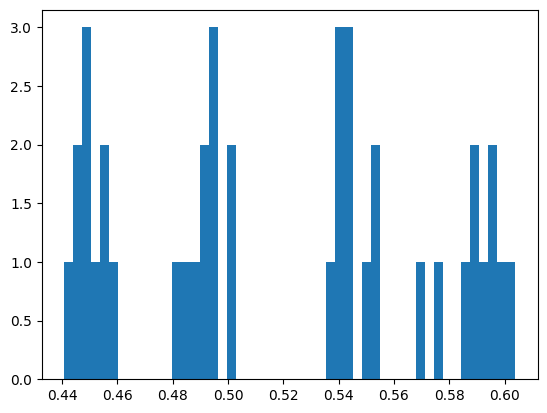

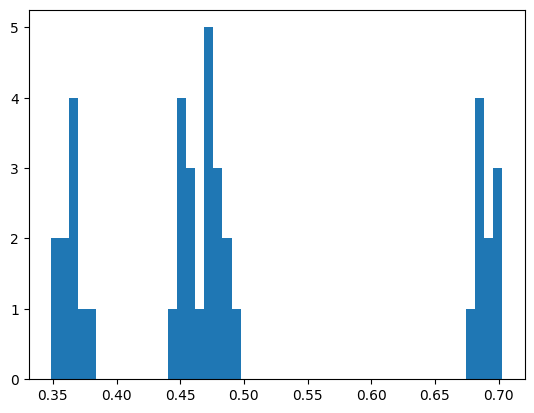

Blackbird solving accuracy: 0.6 (10 puzzles)
Found 2 new solutions out of 6 solved puzzles


In [25]:
check_predictions(full_color_probs, full_position_probs, property_labels[r])